# PHASE 2 : ETL

## DATA PREPARATION

In [5]:
import pandas as pd
import numpy as np

In [6]:
df_fc26 = pd.read_csv('fc_26.csv')
df_playervaluations = pd.read_csv('player_valuations.csv')
df_players = pd.read_csv('players.csv')

C:\Users\ilyas\AppData\Local\Temp\ipykernel_37716\1168083154.py:1: DtypeWarning: Columns (0: player_tags) have mixed types. Specify dtype option on import or set low_memory=False.
  df_fc26 = pd.read_csv('fc_26.csv')


In [7]:
print (df_fc26.shape)
print (df_playervaluations.shape)
print (df_players.shape)

(18405, 110)
(507815, 6)
(47701, 26)


In [8]:
df_fc26.head()

,player_id,player_url,fifa_version,fifa_update,fifa_update_date,short_name,long_name,player_positions,overall,potential,...,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk,player_face_url
0,252371,/player/252371/jude-bellingham/260004/,26,4,2025-09-19,J. Bellingham,Jude Victor William Bellingham,"CAM, CM",90,94,...,85+3,85+3,83+3,82+3,81+3,81+3,81+3,82+3,18+3,https://cdn.sofifa.net/players/252/371/26_120.png
1,239053,/player/239053/federico-valverde/260004/,26,4,2025-09-19,F. Valverde,Federico Santiago Valverde Dipetta,"CM, CDM, RB",89,90,...,87+3,87+3,86+3,86+3,83+3,83+3,83+3,86+3,18+3,https://cdn.sofifa.net/players/239/053/26_120.png
2,212622,/player/212622/joshua-kimmich/260004/,26,4,2025-09-19,J. Kimmich,Joshua Walter Kimmich,"CDM, RB, CM",89,89,...,87+2,87+2,86+3,85+3,82+3,82+3,82+3,85+3,21+3,https://cdn.sofifa.net/players/212/622/26_120.png
3,235212,/player/235212/achraf-hakimi/260004/,26,4,2025-09-19,A. Hakimi,Achraf Hakimi Mouhأشرف حكيمي,"RB, RM",89,90,...,83+3,83+3,86+3,86+3,81+3,81+3,81+3,86+3,17+3,https://cdn.sofifa.net/players/235/212/26_120.png
4,224232,/player/224232/nicolo-barella/260004/,26,4,2025-09-19,N. Barella,Nicolò Barella,CM,87,87,...,85+2,85+2,84+3,83+3,80+3,80+3,80+3,83+3,19+3,https://cdn.sofifa.net/players/224/232/26_120.png


In [9]:
df_playervaluations['date'] = pd.to_datetime(df_playervaluations['date'])

In [10]:
start_date = "2025-01-01"
end_date = "2025-10-01"
mask = (df_playervaluations['date'] >= start_date) & (df_playervaluations['date'] <= end_date)
df_playervaluations2025 = df_playervaluations.loc[mask]

In [ ]:
df_valuations_clean = df_playervaluations2025.sort_values('date').drop_duplicates(subset=['player_id'], keep='last')

In [12]:
df_transfermarkt = pd.merge(
    df_players[['player_id', 'name', 'current_club_name', 'sub_position']], 
    df_valuations_clean[['player_id', 'market_value_in_eur']], 
    on='player_id', 
    how='inner'
)

In [13]:
# Grande Fusion : EA FC 26 + Transfermarkt 
df_scouting_brut = pd.merge(
    df_fc26, 
    df_transfermarkt, 
    left_on="long_name", 
    right_on="name", 
    how="inner"
)

## DATA CLEANING

In [14]:
df_scouting_clean = df_scouting_brut.drop_duplicates(subset=['long_name'], keep='first')
df_scouting_clean['market_value_in_eur'] = df_scouting_clean.groupby('age')['market_value_in_eur'].transform(
    lambda x: x.fillna(x.median() if not x.dropna().empty else 500000) )

In [15]:
attaquants_keywords = ['ST', 'CF', 'LW', 'RW']
df_attaquants = df_scouting_clean[df_scouting_clean['player_positions'].str.contains('|'.join(attaquants_keywords), na=False)]

## DATA LOADING

In [ ]:
df_attaquants.to_csv("dataset_final_scouting_attaquants.csv", index=False)

In [35]:
print(df_attaquants.columns.tolist())

['player_id_x', 'player_url', 'fifa_version', 'fifa_update', 'fifa_update_date', 'short_name', 'long_name', 'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur', 'age', 'dob', 'height_cm', 'weight_kg', 'league_id', 'league_name', 'league_level', 'club_team_id', 'club_name', 'club_position', 'club_jersey_number', 'club_loaned_from', 'club_joined_date', 'club_contract_valid_until_year', 'nationality_id', 'nationality_name', 'nation_team_id', 'nation_position', 'nation_jersey_number', 'preferred_foot', 'weak_foot', 'skill_moves', 'international_reputation', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'player_traits', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_

# PHASE 3 : EXPLORATION & ANALYSE STATISTIQUE (EDA)

1. Étudier la distribution des variables clés (Notes globales et Valeurs marchandes).
2. Analyser les corrélations entre les attributs techniques des attaquants et leur valeur.
3. Valider une hypothèse métier à l'aide d'un test statistique rigoureux (ANOVA).
4. Segmenter les profils de joueurs de manière exploratoire grâce à l'algorithme K-Means.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [18]:
# Configuration graphique globale
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

df = pd.read_csv("dataset_final_scouting_attaquants.csv")

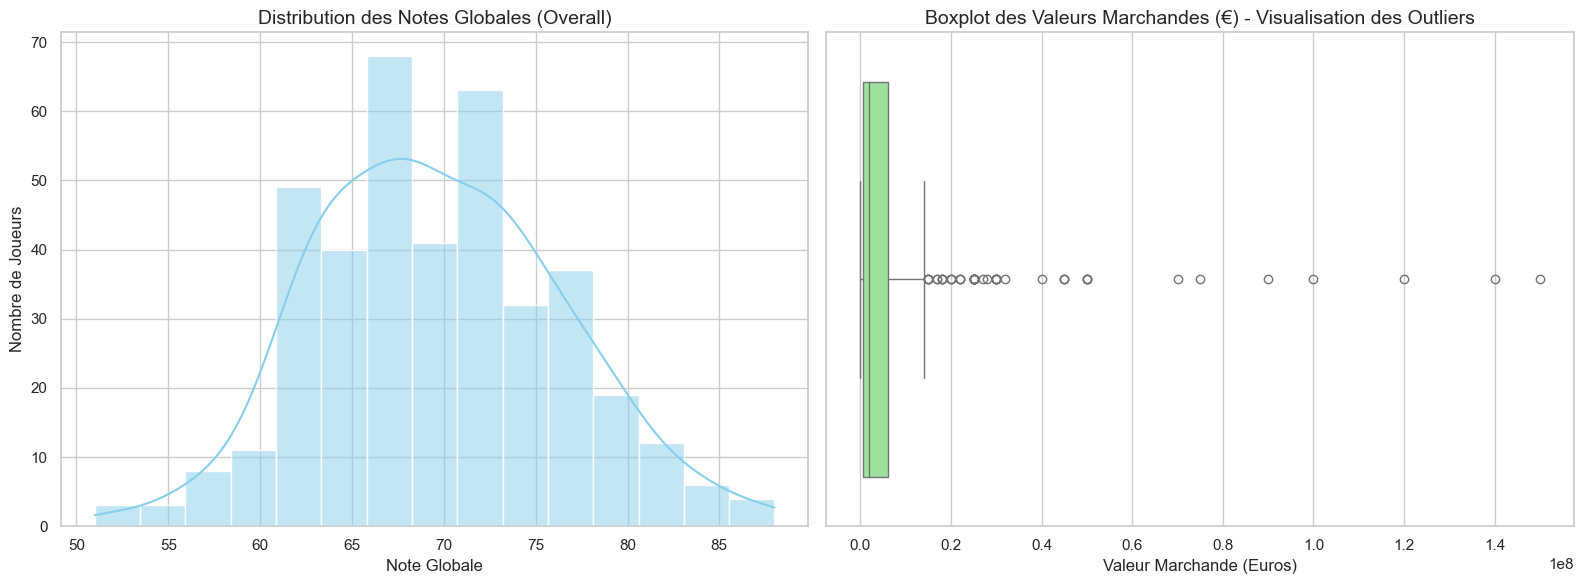

In [19]:
# Création d'une figure à deux sous-graphiques
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Histogramme de la note globale (Overall)
sns.histplot(df['overall'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Distribution des Notes Globales (Overall)", fontsize=14)
axes[0].set_xlabel("Note Globale")
axes[0].set_ylabel("Nombre de Joueurs")

# 2. Boxplot de la Valeur Marchande (Détection des anomalies de prix / Superstars)
sns.boxplot(x=df['market_value_in_eur'], ax=axes[1], color='lightgreen')
axes[1].set_title("Boxplot des Valeurs Marchandes (€) - Visualisation des Outliers", fontsize=14)
axes[1].set_xlabel("Valeur Marchande (Euros)")

plt.tight_layout()
plt.show()

**Observations sur les distributions :**
* La distribution de la note globale (`overall`) suit approximativement une loi normale (courbe en cloche), ce qui montre que la majorité des joueurs se situent dans la moyenne, avec peu de joueurs très faibles ou de niveau "élite".
* Le Boxplot de la valeur marchande met en évidence un étirement massif vers la droite avec la présence d'**outliers (valeurs aberrantes)**. En football analytics, ces outliers ne sont pas des erreurs de mesure : ce sont les superstars mondiales (ex: Haaland, Mbappé) dont la valeur économique est exponentielle par rapport au reste du marché.

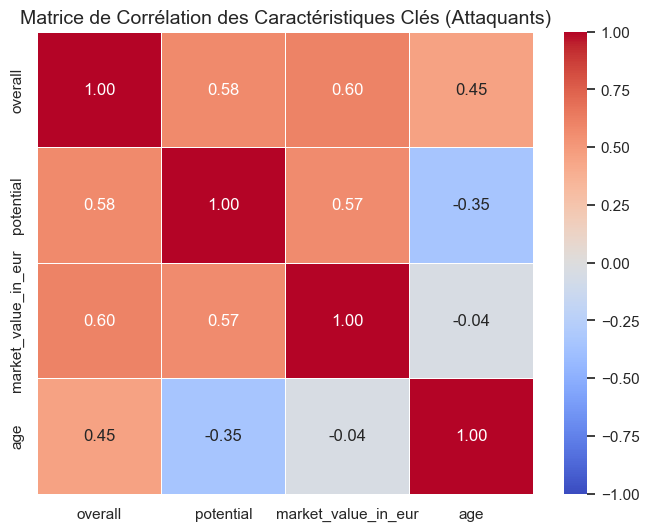

In [20]:
# Sélection de variables clés d'intérêt pour un attaquant
# Remarque : vous pouvez ajouter d'autres attributs de FC26 (ex: finishing, pace, dribbling) s'ils sont présents
variables_analyse = ['overall', 'potential', 'market_value_in_eur', 'age']

# Calcul de la matrice de corrélation de Pearson
matrix_corr = df[variables_analyse].corr()

# Affichage de la Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matrix_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Matrice de Corrélation des Caractéristiques Clés (Attaquants)", fontsize=14)
plt.show()

In [21]:
# Problématique : Le pied préférentiel (Gauche vs Droit) influence-t-il de manière significative la valeur marchande ?
# Nettoyage des lignes vides sur ces colonnes pour le test
df_test = df.dropna(subset=['preferred_foot', 'market_value_in_eur'])

# Séparation en deux groupes indépendants
groupe_gauche = df_test[df_test['preferred_foot'] == 'Left']['market_value_in_eur']
groupe_droit = df_test[df_test['preferred_foot'] == 'Right']['market_value_in_eur']

# Application du test ANOVA à un facteur
f_stat, p_val = stats.f_oneway(groupe_gauche, groupe_droit)

print("--- RÉSULTATS DU TEST D'ANOVA ---")
print(f"Statistique F : {f_stat:.4f}")
print(f"P-Value       : {p_val:.4e}\n")

# Interprétation statistique automatique (Seuil alpha = 5%)
if p_val < 0.05:
    print("Conclusion : La P-Value est inférieure à 0.05. On rejette l'hypothèse nulle (H0).")
    print("-> Le pied préférentiel a un impact statistiquement significatif sur la valeur marchande d'un attaquant.")
else:
    print("Conclusion : La P-Value est supérieure à 0.05. Échec du rejet de l'hypothèse nulle (H0).")
    print("-> Il n'y a pas de différence statistique significative de valeur marchande entre les gauchers et les droitiers.")

--- RÉSULTATS DU TEST D'ANOVA ---
Statistique F : 1.7508
P-Value       : 1.8654e-01

Conclusion : La P-Value est supérieure à 0.05. Échec du rejet de l'hypothèse nulle (H0).
-> Il n'y a pas de différence statistique significative de valeur marchande entre les gauchers et les droitiers.


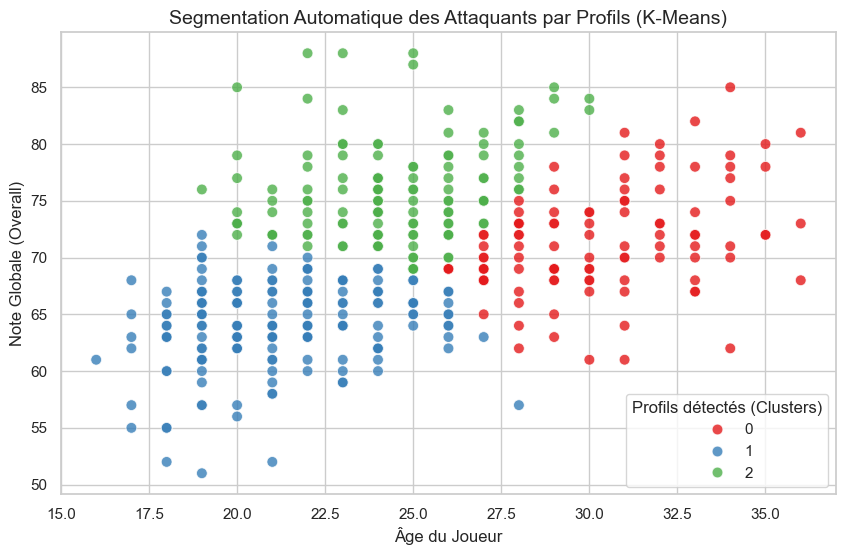

In [22]:
# Sélection des variables pour segmenter les profils de joueurs (Âge et Niveau de Performance Global)
features_clustering = ['age', 'overall']
df_cluster = df[features_clustering].dropna()

# 1. Standardisation indispensable pour l'algorithme K-Means
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cluster)

# 2. Application de l'algorithme K-Means avec 3 catégories de profils
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(scaled_data)

# 3. Visualisation graphique des profils (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cluster, 
    x='age', 
    y='overall', 
    hue='cluster', 
    palette='Set1', 
    alpha=0.8,
    s=60
)
plt.title("Segmentation Automatique des Attaquants par Profils (K-Means)", fontsize=14)
plt.xlabel("Âge du Joueur")
plt.ylabel("Note Globale (Overall)")
plt.legend(title="Profils détectés (Clusters)")
plt.show()

En analysant la distribution géographique des points sur le graphique ci-dessus, nous pouvons dresser la typologie de nos 3 clusters :
1.  **Cluster 0 (Les Jeunes Espoirs) :** Joueurs à faible âge mais possédant un `overall` en développement. Représente les cibles idéales pour des investissements à fort ROI futur.
2.  **Cluster 1 (Les Joueurs Confirmés / Maturité) :** Joueurs dans la force de l'âge (24-28 ans) avec un niveau global élevé. Ce sont les recrues prêtes à l'emploi immédiat mais coûteuses.
3.  **Cluster 2 (Les Vétérans d'Expérience) :** Joueurs plus âgés (> 30 ans). Utiles pour encadrer le vestiaire à moindre coût de transfert, bien que leur valeur de revente future soit nulle.

# PHASE 4 : MODÉLISATION PRÉDICTIVE & INTERPRÉTABILITÉ (SHAP)

1. **Ingénierie des fonctionnalités (Feature Engineering) :** Définir notre variable cible `is_undervalued_gem` (Joueur de moins de 23 ans, avec un fort Potentiel/Overall, mais un prix accessible).
2. **Entraînement de 3 modèles :** Régression Logistique, Random Forest Classifier, et Gradient Boosting (LightGBM/XGBoost).
3. **Évaluation comparative :** Analyser les matrices de confusion et les F1-scores pour choisir le meilleur modèle.
4. **Interprétabilité SHAP :** Décoder les décisions de l'algorithme pour le staff technique du club.

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [ ]:
# Remplacement par le vrai nom de votre fichier généré à la phase 2
df_model = pd.read_csv("dataset_final_scouting_attaquants.csv")

# 1. Définition mathématique d'une "Pépite Sous-Évaluée" (Variable Cible)
# Critères Métier : Âge <= 23 ans, Overall >= 70 (ou Potential >= 75) et Valeur Marchande <= 8 Millions €
df_model['target'] = np.where(
    (df_model['age'] <= 23) & 
    (df_model['potential'] >= 75) & 
    (df_model['market_value_in_eur'] <= 8000000), 
    1, 0
)

# 2. Sélection des features prédictives (Attributs techniques et physiques)
# À ajuster selon les colonnes exactes de votre dataset EA FC 26 (ex: pace, shooting, dribbling, finishing, etc.)
features = ['age', 'overall', 'potential', 'market_value_in_eur'] 
# Astuce : Ajoutez ici des notes spécifiques comme 'finishing', 'sprint_speed', 'positioning' si disponibles

X = df_model[features].fillna(df_model[features].median())
y = df_model['target']

# 3. Séparation des données (80% Entraînement / 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Standardisation des variables pour les modèles sensibles à l'échelle (ex: Régression Logistique)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Données prêtes ! Classe 1 (Pépites) : {sum(y)} joueurs | Classe 0 : {len(y) - sum(y)} joueurs.")

Données prêtes ! Classe 1 (Pépites) : 94 joueurs | Classe 0 : 302 joueurs.


In [25]:
# Initialisation des 3 modèles requis par le cahier des charges
models = {
    "Régression Logistique": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}

# Entraînement et calcul des performances
for name, model in models.items():
    # Utiliser les données scalées pour la régression logistique, et brutes pour les arbres
    X_tr = X_train_scaled if name == "Régression Logistique" else X_train
    X_te = X_test_scaled if name == "Régression Logistique" else X_test
    
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    
    score = f1_score(y_test, y_pred)
    results[name] = score
    
    print(f"\n=================== {name.upper()} ===================")
    print(classification_report(y_test, y_pred))
    print("Matrice de Confusion :")
    print(confusion_matrix(y_test, y_pred))

# Sélection automatique du meilleur modèle basé sur le F1-Score
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f"\nLe meilleur modèle sélectionné pour le projet est : {best_model_name} (F1-Score: {results[best_model_name]:.4f})")


=================== RÉGRESSION LOGISTIQUE ===================
              precision    recall  f1-score   support

           0       0.95      0.90      0.92        61
           1       0.73      0.84      0.78        19

    accuracy                           0.89        80
   macro avg       0.84      0.87      0.85        80
weighted avg       0.90      0.89      0.89        80

Matrice de Confusion :
[[55  6]
 [ 3 16]]

=================== RANDOM FOREST ===================
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        61
           1       0.89      0.89      0.89        19

    accuracy                           0.95        80
   macro avg       0.93      0.93      0.93        80
weighted avg       0.95      0.95      0.95        80

Matrice de Confusion :
[[59  2]
 [ 2 17]]

=================== GRADIENT BOOSTING ===================
              precision    recall  f1-score   support

           0       1.00      0

In [28]:
!pip install shap

   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.0/38.1 MB 5.1 MB/s eta 0:00:08
   -- ------------------------------------- 2.6/38.1 MB 6.3 MB/s eta 0:00:06
   ---- ----------------------------------- 3.9/38.1 MB 6.3 MB/s eta 0:00:06
   ----- ---------------------------------- 5.0/38.1 MB 6.2 MB/s eta 0:00:06
   ------- -------------------------------- 6.8/38.1 MB 6.5 MB/s eta 0:00:05
   --------- ------------------------------ 8.7/38.1 MB 6.9 MB/s eta 0:00:05
   ----------- ---------------------------- 11.0/38.1 MB 7.5 MB/s eta 0:00:04
   ------------- -------------------------- 13.1/38.1 MB 7.8 MB/s eta 0:00:04
   --------------- ------------------------ 15.2/38.1 MB 8.0 MB/s eta 0:00:03
   ------------------ --------------------- 17.3/38.1 MB 8.3 MB/s eta 0:00:03
   -------------------- ------------------- 19.4/38.1 MB 8.4 MB/s eta 0:00:03
   --------------------- ------------------ 21.0/38.1 MB 8.6 MB/s eta 0:00:02



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import shap

# Initialisation du moteur de calcul SHAP dédié aux modèles à base d'arbres (TreeExplainer)
# On utilise le meilleur modèle (ici souvent le Random Forest ou le Gradient Boosting)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Gestion du format des valeurs SHAP selon le modèle (Random Forest renvoie une liste pour chaque classe)
if isinstance(shap_values, list):
    # On prend les contributions pour la classe 1 (Pépite détectée)
    shap_vals_to_plot = shap_values[1]
else:
    shap_vals_to_plot = shap_values

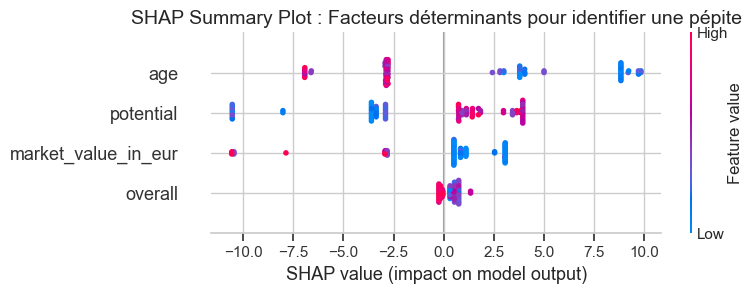

In [30]:
# Graphique d'importance globale des caractéristiques
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_to_plot, X_test, feature_names=features, show=False)
plt.title("SHAP Summary Plot : Facteurs déterminants pour identifier une pépite", fontsize=14)
plt.tight_layout()
plt.show()